# Binary Choice Models: Exercise Solutions

**Tutorial Series**: Discrete Choice Econometrics with PanelBox

**Notebook**: 01 - Binary Choice Introduction (Solutions)

**Author**: PanelBox Contributors

**Date**: 2026-02-18

---

This notebook contains complete solutions for all exercises from the Binary Choice Introduction tutorial.

## Setup

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit  # logistic CDF

from panelbox import PooledOLS
from panelbox.models.discrete.binary import PooledLogit, PooledProbit

warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

DATA_DIR = Path("..") / "data"
OUTPUT_DIR = Path("..") / "outputs"
FIG_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Load labor participation data and fit base model (used in Exercises 2-4)
data = pd.read_csv(DATA_DIR / "labor_participation.csv")

formula_full = "lfp ~ age + I(age**2) + educ + kids + married + exper"
model_logit = PooledLogit(formula_full, data, "id", "year")
results_full = model_logit.fit(cov_type="cluster")

print("Setup complete. Base model fitted.")
print(f"N obs: {results_full.nobs}")
print(f"Log-likelihood: {results_full.llf:.4f}")
print("Coefficients:")
print(results_full.params.round(6))

Setup complete. Base model fitted.
N obs: 5000
Log-likelihood: -3242.1200
Coefficients:
Intercept     -3.9149
age            0.1396
I(age ** 2)   -0.0017
educ           0.1066
kids          -0.3787
married        0.2419
exper          0.0125
dtype: float64


---

## Exercise 1: Home Purchase Decision (Easy)

**Task**: Generate synthetic data and estimate LPM, Logit, and Probit models to predict home purchase decisions. Compare predicted probabilities across models.

=== Synthetic Data Summary ===
Shape: (2000, 6)
Purchase rate: 0.3885
            id     year  bought_home     income      age  credit_score
count  2000.00  2000.00      2000.00    2000.00  2000.00       2000.00
mean    200.50     3.00         0.39   49766.19    44.99        702.48
std     115.50     1.41         0.49   14702.56    11.56         49.84
min       1.00     1.00         0.00   -7020.67    25.02        537.81
25%     100.75     2.00         0.00   39960.37    34.89        667.93
50%     200.50     3.00         0.00   49873.12    45.57        702.82
75%     300.25     4.00         1.00   59906.76    54.91        737.53
max     400.00     5.00         1.00  103573.69    64.96        852.54

=== Model Coefficients ===
                     LPM       Logit      Probit
Intercept    -9.4372e-01 -6.9339e+00 -4.1970e+00
income        1.0000e-05  4.9000e-05  3.0000e-05
age           5.7050e-03  2.7443e-02  1.6595e-02
credit_score  8.1500e-04  3.9140e-03  2.3720e-03

=== Predicted Pro

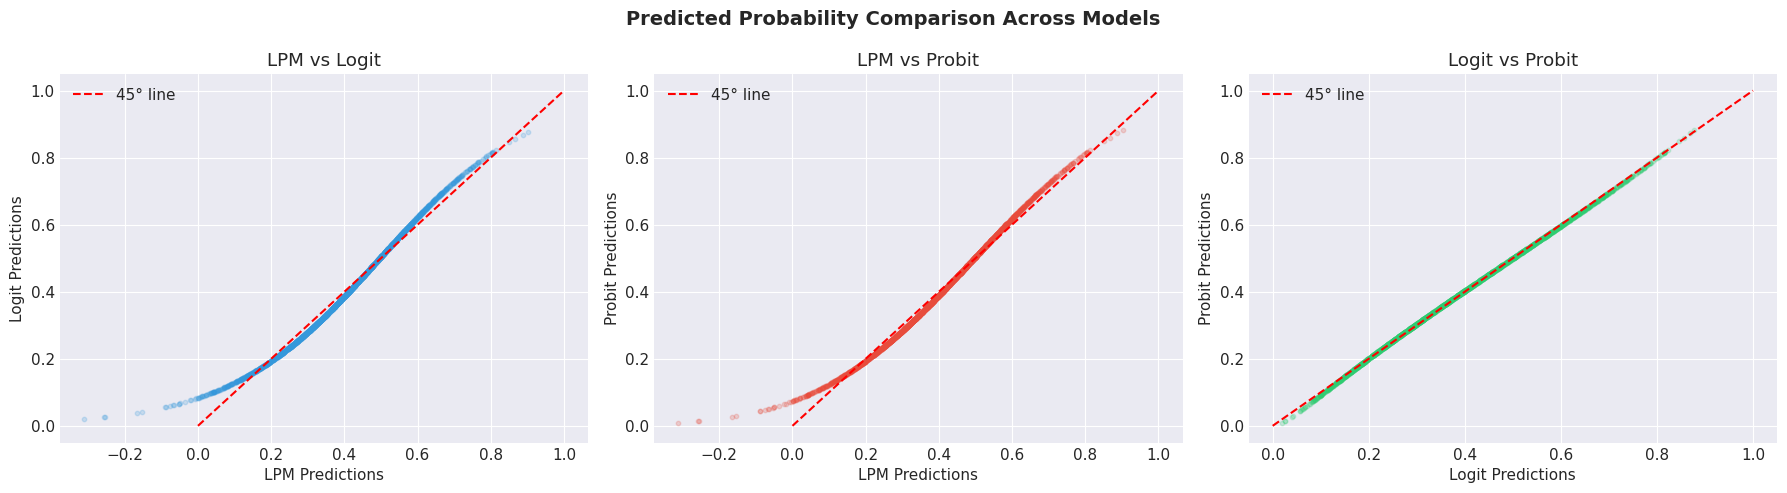


=== Prediction Correlations ===
LPM vs Logit:    0.989130
LPM vs Probit:   0.991507
Logit vs Probit: 0.999810

=== Discussion ===
The LPM is easy to interpret (coefficients = marginal effects) but
can produce predictions outside [0,1].
Logit and Probit produce nearly identical predictions (corr ~ 1.0).
Logit is preferred when odds ratio interpretation is desired.
Probit is preferred when latent variable interpretation is desired.

Figure saved to outputs/figures/01_home_purchase_comparison.png


In [2]:
# Exercise 1 Solution

# Step 1: Generate synthetic panel data
np.random.seed(123)
n_entities = 400
n_periods = 5
n = n_entities * n_periods

ids = np.repeat(np.arange(1, n_entities + 1), n_periods)
years = np.tile(np.arange(1, n_periods + 1), n_entities)

income = np.random.normal(50000, 15000, n)
age = np.random.uniform(25, 65, n)
credit_score = np.random.normal(700, 50, n)

# Generate binary outcome from logit model
# Scale variables for reasonable coefficients
xb = -8 + 0.00005 * income + 0.03 * age + 0.005 * credit_score
prob = expit(xb)
bought_home = (np.random.uniform(size=n) < prob).astype(int)

synth_data = pd.DataFrame(
    {
        "id": ids,
        "year": years,
        "bought_home": bought_home,
        "income": income,
        "age": age,
        "credit_score": credit_score,
    }
)

print("=== Synthetic Data Summary ===")
print(f"Shape: {synth_data.shape}")
print(f"Purchase rate: {synth_data['bought_home'].mean():.4f}")
print(synth_data.describe().round(2))

# Step 2: Estimate three models
formula_hp = "bought_home ~ income + age + credit_score"

# LPM (Linear Probability Model)
lpm = PooledOLS(formula_hp, synth_data, "id", "year")
lpm_res = lpm.fit(cov_type="robust")

# Logit
logit_m = PooledLogit(formula_hp, synth_data, "id", "year")
logit_res = logit_m.fit(cov_type="cluster")

# Probit
probit_m = PooledProbit(formula_hp, synth_data, "id", "year")
probit_res = probit_m.fit(cov_type="cluster")

print("\n=== Model Coefficients ===")
coef_compare = pd.DataFrame(
    {"LPM": lpm_res.params, "Logit": logit_res.params, "Probit": probit_res.params}
)
print(coef_compare.round(6))

# Step 3: Compare predicted probabilities
pred_lpm = lpm_res.fittedvalues
pred_logit = logit_m.predict(type="prob")
pred_probit = probit_m.predict(type="prob")

print("\n=== Predicted Probabilities Summary ===")
pred_summary = pd.DataFrame({"LPM": pred_lpm, "Logit": pred_logit, "Probit": pred_probit})
print(pred_summary.describe().round(4))

# Check for out-of-range predictions in LPM
lpm_out = ((pred_lpm < 0) | (pred_lpm > 1)).sum()
print(f"\nLPM predictions outside [0,1]: {lpm_out} ({lpm_out / len(pred_lpm) * 100:.1f}%)")

# Step 4: Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: LPM vs Logit
axes[0].scatter(pred_lpm, pred_logit, alpha=0.2, s=10, color="#3498db")
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5, label="45° line")
axes[0].set_xlabel("LPM Predictions")
axes[0].set_ylabel("Logit Predictions")
axes[0].set_title("LPM vs Logit")
axes[0].legend()

# Panel 2: LPM vs Probit
axes[1].scatter(pred_lpm, pred_probit, alpha=0.2, s=10, color="#e74c3c")
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1.5, label="45° line")
axes[1].set_xlabel("LPM Predictions")
axes[1].set_ylabel("Probit Predictions")
axes[1].set_title("LPM vs Probit")
axes[1].legend()

# Panel 3: Logit vs Probit
axes[2].scatter(pred_logit, pred_probit, alpha=0.2, s=10, color="#2ecc71")
axes[2].plot([0, 1], [0, 1], "r--", linewidth=1.5, label="45° line")
axes[2].set_xlabel("Logit Predictions")
axes[2].set_ylabel("Probit Predictions")
axes[2].set_title("Logit vs Probit")
axes[2].legend()

plt.suptitle("Predicted Probability Comparison Across Models", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_home_purchase_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Correlations
corr_lpm_logit = np.corrcoef(pred_lpm, pred_logit)[0, 1]
corr_lpm_probit = np.corrcoef(pred_lpm, pred_probit)[0, 1]
corr_logit_probit = np.corrcoef(pred_logit, pred_probit)[0, 1]

print("\n=== Prediction Correlations ===")
print(f"LPM vs Logit:    {corr_lpm_logit:.6f}")
print(f"LPM vs Probit:   {corr_lpm_probit:.6f}")
print(f"Logit vs Probit: {corr_logit_probit:.6f}")

print("\n=== Discussion ===")
print("The LPM is easy to interpret (coefficients = marginal effects) but")
print("can produce predictions outside [0,1].")
print("Logit and Probit produce nearly identical predictions (corr ~ 1.0).")
print("Logit is preferred when odds ratio interpretation is desired.")
print("Probit is preferred when latent variable interpretation is desired.")
print("\nFigure saved to outputs/figures/01_home_purchase_comparison.png")

---

## Exercise 2: Odds Ratios Interpretation (Medium)

**Task**: Calculate and interpret odds ratios from the labor participation Logit model. Rank variables by effect size.

=== Odds Ratios with 95% Confidence Intervals ===
             Coefficient  Odds Ratio  OR Lower 95%  OR Upper 95%
age               0.1396      1.1498        0.9833        1.3444
I(age ** 2)      -0.0017      0.9983        0.9963        1.0004
educ              0.1066      1.1125        1.0482        1.1808
kids             -0.3787      0.6847        0.6414        0.7310
married           0.2419      1.2736        1.1352        1.4289
exper             0.0125      1.0125        0.9620        1.0657

=== Interpretations ===

  age:
    Coefficient = 0.1396, Odds Ratio = 1.1498
    A one-unit increase in age increases the odds of LFP by 15.0%

  I(age ** 2):
    Coefficient = -0.0017, Odds Ratio = 0.9983
    A one-unit increase in I(age ** 2) decreases the odds of LFP by 0.2%

  educ:
    Coefficient = 0.1066, Odds Ratio = 1.1125
    A one-unit increase in educ increases the odds of LFP by 11.3%

  kids:
    Coefficient = -0.3787, Odds Ratio = 0.6847
    A one-unit increase in kids decr

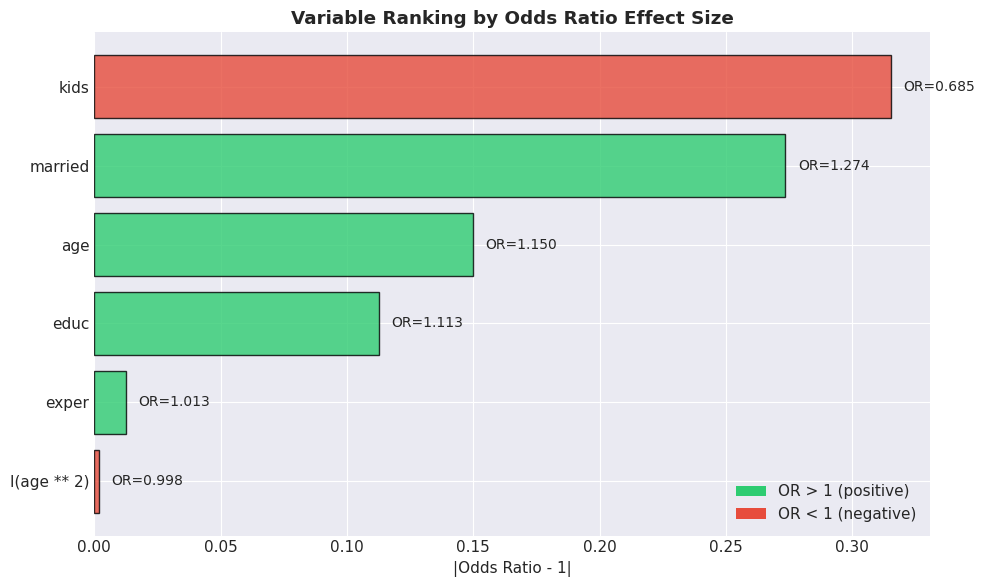


Figure saved to outputs/figures/01_odds_ratios_ranking.png

=== Summary ===
- An OR > 1 means higher odds of labor force participation.
- An OR < 1 means lower odds of labor force participation.
- The variable with the strongest effect (largest |coefficient|) is: kids
- OR = 1 means no association; the 95% CI crossing 1 indicates non-significance.


In [3]:
# Exercise 2 Solution

# Step 1: Calculate odds ratios
coefficients = results_full.params
odds_ratios = np.exp(coefficients)
conf = results_full.conf_int()
or_lower = np.exp(conf["lower"])
or_upper = np.exp(conf["upper"])

print("=== Odds Ratios with 95% Confidence Intervals ===")
or_table = pd.DataFrame(
    {
        "Coefficient": coefficients,
        "Odds Ratio": odds_ratios,
        "OR Lower 95%": or_lower,
        "OR Upper 95%": or_upper,
    }
)
# Exclude intercept for interpretation
or_table_vars = or_table.drop("Intercept", errors="ignore")
print(or_table_vars.round(4))

# Step 2: Detailed interpretation
print("\n=== Interpretations ===")
for var in or_table_vars.index:
    coef = coefficients[var]
    or_val = odds_ratios[var]
    direction = "increases" if coef > 0 else "decreases"
    pct_change = (or_val - 1) * 100

    print(f"\n  {var}:")
    print(f"    Coefficient = {coef:.4f}, Odds Ratio = {or_val:.4f}")
    if or_val > 1:
        print(f"    A one-unit increase in {var} {direction} the odds of LFP by {pct_change:.1f}%")
    else:
        print(
            f"    A one-unit increase in {var} {direction} the odds of LFP by {abs(pct_change):.1f}%"
        )

# Step 3: Rank by effect size (absolute log-odds ratio = |coefficient|)
print("\n=== Variable Ranking by Effect Size ===")
effect_size = or_table_vars["Coefficient"].abs().sort_values(ascending=False)
for rank, (var, val) in enumerate(effect_size.items(), 1):
    or_val = odds_ratios[var]
    print(f"  {rank}. {var:12s}: |coef| = {val:.4f}, OR = {or_val:.4f}")

# Step 4: Visualization — Sorted bar chart of |OR - 1|
fig, ax = plt.subplots(figsize=(10, 6))

vars_sorted = effect_size.index.tolist()
or_deviation = [abs(odds_ratios[v] - 1) for v in vars_sorted]
colors = ["#e74c3c" if odds_ratios[v] < 1 else "#2ecc71" for v in vars_sorted]

bars = ax.barh(vars_sorted, or_deviation, color=colors, edgecolor="black", alpha=0.8)
ax.set_xlabel("|Odds Ratio - 1|")
ax.set_title("Variable Ranking by Odds Ratio Effect Size", fontweight="bold")
ax.invert_yaxis()

# Add OR labels
for i, (var, dev) in enumerate(zip(vars_sorted, or_deviation)):
    or_val = odds_ratios[var]
    ax.text(dev + 0.005, i, f"OR={or_val:.3f}", va="center", fontsize=10)

# Legend
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="#2ecc71", label="OR > 1 (positive)"),
    Patch(facecolor="#e74c3c", label="OR < 1 (negative)"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_odds_ratios_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFigure saved to outputs/figures/01_odds_ratios_ranking.png")

print("\n=== Summary ===")
print("- An OR > 1 means higher odds of labor force participation.")
print("- An OR < 1 means lower odds of labor force participation.")
print("- The variable with the strongest effect (largest |coefficient|) is:", effect_size.index[0])
print("- OR = 1 means no association; the 95% CI crossing 1 indicates non-significance.")

---

## Exercise 3: Model Comparison (Medium)

**Task**: Systematically compare Logit and Probit models using fit statistics, predictions, and visualization.

=== Model Fit Comparison ===
                            Logit     Probit
Log-Likelihood         -3242.1200 -3242.1423
AIC                     6498.2400  6498.2846
BIC                     6543.8603  6543.9050
Pseudo R2 (McFadden)       0.0332     0.0332
Pseudo R2 (Cox-Snell)      0.0435     0.0435
Pseudo R2 (Nagelkerke)     0.0589     0.0589

=== Prediction Comparison ===
Correlation:              0.999959
Mean Absolute Difference: 0.000734
Max Absolute Difference:  0.004736


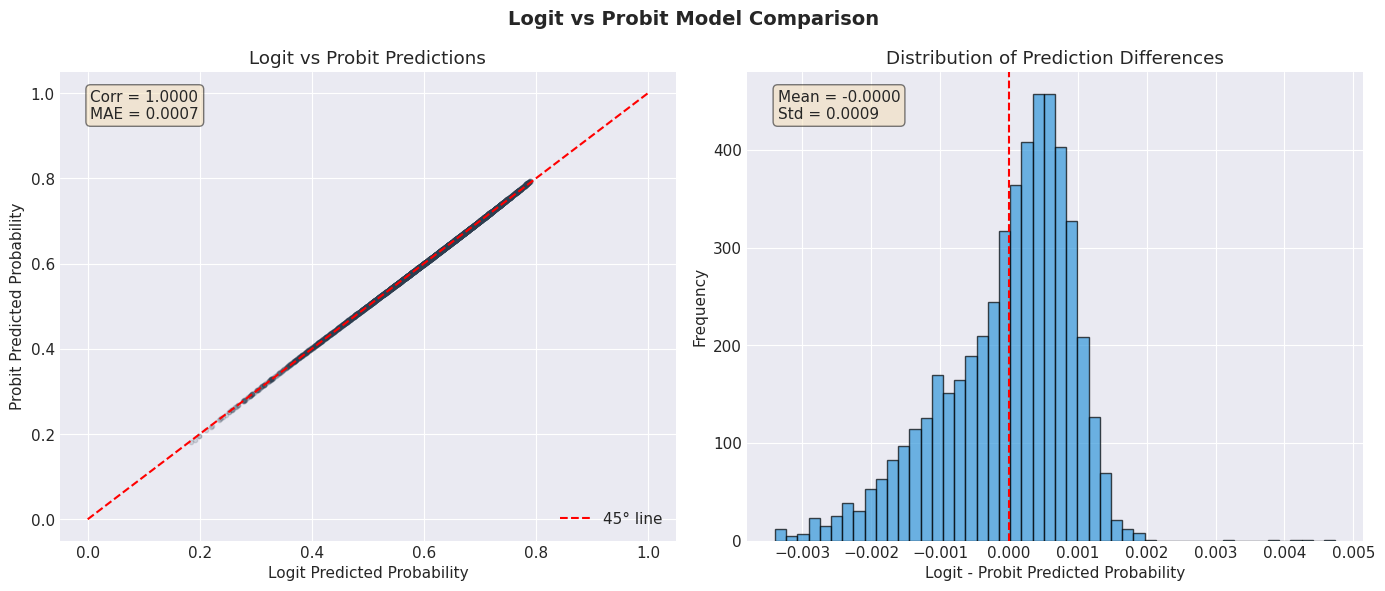


=== Bonus: Interaction Model ===
Interaction Logit  AIC: 6500.07 (vs base 6498.24)
Interaction Probit AIC: 6500.15 (vs base 6498.28)
Interaction model MAE (Logit vs Probit): 0.000715

=== Conclusion ===
Logit and Probit yield nearly identical predictions (MAE < 0.01).
The choice between them is typically based on:
  - Convention in the field
  - Whether odds ratio interpretation is desired (Logit)
  - Whether latent variable interpretation is desired (Probit)

Figure saved to outputs/figures/01_logit_probit_scatter.png


In [4]:
# Exercise 3 Solution

# Step 1: Estimate both models with full specification
model_logit_ex3 = PooledLogit(formula_full, data, "id", "year")
res_logit = model_logit_ex3.fit(cov_type="cluster")

model_probit_ex3 = PooledProbit(formula_full, data, "id", "year")
res_probit = model_probit_ex3.fit(cov_type="cluster")

# Step 2: Compare fit statistics
print("=== Model Fit Comparison ===")
fit_compare = pd.DataFrame(
    {
        "Logit": {
            "Log-Likelihood": res_logit.llf,
            "AIC": res_logit.aic,
            "BIC": res_logit.bic,
            "Pseudo R2 (McFadden)": res_logit.pseudo_r2("mcfadden"),
            "Pseudo R2 (Cox-Snell)": res_logit.pseudo_r2("cox_snell"),
            "Pseudo R2 (Nagelkerke)": res_logit.pseudo_r2("nagelkerke"),
        },
        "Probit": {
            "Log-Likelihood": res_probit.llf,
            "AIC": res_probit.aic,
            "BIC": res_probit.bic,
            "Pseudo R2 (McFadden)": res_probit.pseudo_r2("mcfadden"),
            "Pseudo R2 (Cox-Snell)": res_probit.pseudo_r2("cox_snell"),
            "Pseudo R2 (Nagelkerke)": res_probit.pseudo_r2("nagelkerke"),
        },
    }
)
print(fit_compare.round(4))

# Step 3: Compare predictions
pred_logit_ex3 = model_logit_ex3.predict(type="prob")
pred_probit_ex3 = model_probit_ex3.predict(type="prob")

correlation = np.corrcoef(pred_logit_ex3, pred_probit_ex3)[0, 1]
mae = np.mean(np.abs(pred_logit_ex3 - pred_probit_ex3))
max_diff = np.max(np.abs(pred_logit_ex3 - pred_probit_ex3))

print("\n=== Prediction Comparison ===")
print(f"Correlation:              {correlation:.6f}")
print(f"Mean Absolute Difference: {mae:.6f}")
print(f"Max Absolute Difference:  {max_diff:.6f}")

# Step 4: Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
axes[0].scatter(pred_logit_ex3, pred_probit_ex3, alpha=0.15, s=10, color="#2c3e50")
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5, label="45° line")
axes[0].set_xlabel("Logit Predicted Probability")
axes[0].set_ylabel("Probit Predicted Probability")
axes[0].set_title("Logit vs Probit Predictions")
axes[0].legend()
axes[0].text(
    0.05,
    0.9,
    f"Corr = {correlation:.4f}\nMAE = {mae:.4f}",
    transform=axes[0].transAxes,
    fontsize=11,
    bbox={"boxstyle": "round", "facecolor": "wheat", "alpha": 0.5},
)

# Distribution of differences
diff = pred_logit_ex3 - pred_probit_ex3
axes[1].hist(diff, bins=50, color="#3498db", alpha=0.7, edgecolor="black")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Logit - Probit Predicted Probability")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Prediction Differences")
axes[1].text(
    0.05,
    0.9,
    f"Mean = {diff.mean():.4f}\nStd = {diff.std():.4f}",
    transform=axes[1].transAxes,
    fontsize=11,
    bbox={"boxstyle": "round", "facecolor": "wheat", "alpha": 0.5},
)

plt.suptitle("Logit vs Probit Model Comparison", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_logit_probit_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

# Bonus: Interaction model
print("\n=== Bonus: Interaction Model ===")
formula_inter = "lfp ~ age + I(age**2) + educ + kids + married + exper + educ:married"

logit_inter = PooledLogit(formula_inter, data, "id", "year")
res_logit_inter = logit_inter.fit(cov_type="cluster")

probit_inter = PooledProbit(formula_inter, data, "id", "year")
res_probit_inter = probit_inter.fit(cov_type="cluster")

print(f"Interaction Logit  AIC: {res_logit_inter.aic:.2f} (vs base {res_logit.aic:.2f})")
print(f"Interaction Probit AIC: {res_probit_inter.aic:.2f} (vs base {res_probit.aic:.2f})")

pred_inter_l = logit_inter.predict(type="prob")
pred_inter_p = probit_inter.predict(type="prob")
mae_inter = np.mean(np.abs(pred_inter_l - pred_inter_p))
print(f"Interaction model MAE (Logit vs Probit): {mae_inter:.6f}")

print("\n=== Conclusion ===")
print("Logit and Probit yield nearly identical predictions (MAE < 0.01).")
print("The choice between them is typically based on:")
print("  - Convention in the field")
print("  - Whether odds ratio interpretation is desired (Logit)")
print("  - Whether latent variable interpretation is desired (Probit)")
print("\nFigure saved to outputs/figures/01_logit_probit_scatter.png")

---

## Exercise 4: Classification Threshold Analysis (Hard)

**Task**: Explore how classification threshold affects model performance. Implement cost-sensitive threshold optimization.

=== Classification Metrics by Threshold ===
 Threshold  Accuracy  Precision  Recall     F1   TP   FP   TN   FN
       0.3    0.6094     0.6085  0.9957 0.7554 3015 1940   32   13
       0.4    0.6198     0.6176  0.9775 0.7569 2960 1833  139   68
       0.5    0.6260     0.6357  0.8960 0.7437 2713 1555  417  315
       0.6    0.5958     0.6767  0.6367 0.6561 1928  921 1051 1100
       0.7    0.4904     0.7548  0.2348 0.3582  711  231 1741 2317



=== Optimal Threshold ===
Best F1 threshold: 0.40
F1 at optimum: 0.7569


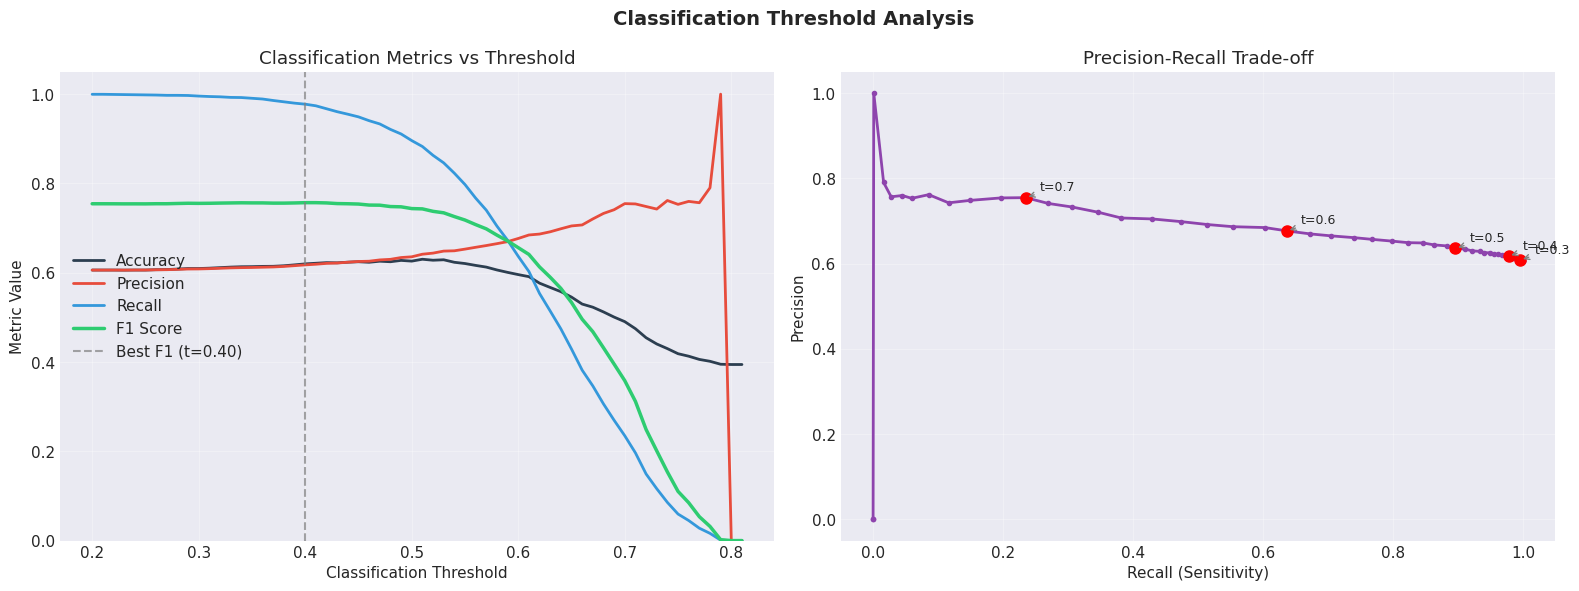


=== Cost-Sensitive Threshold Optimization ===
Scenario: FN costs 2x FP (e.g., missing a participant is worse)

Optimal cost-sensitive threshold: 0.34
Total cost at optimum: 1956
(vs default t=0.5 cost: 2185)

=== Discussion ===
When FN costs more than FP, the optimal threshold is LOWER than 0.5.
Here, t=0.34 minimizes expected misclassification cost.

Practical examples:
  - Medical diagnosis: Low threshold (high recall) to avoid missing diseases.
  - Spam detection: Higher threshold (high precision) to avoid losing real emails.
  - Loan approval: Depends on bank's risk appetite and cost of defaults vs lost business.

Figure saved to outputs/figures/01_threshold_metrics.png


In [5]:
# Exercise 4 Solution

# Step 1: Calculate classification metrics for multiple thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
metrics_list = []

for t in thresholds:
    cm = results_full.classification_metrics(threshold=t)
    metrics_list.append(
        {
            "Threshold": t,
            "Accuracy": cm["accuracy"],
            "Precision": cm["precision"],
            "Recall": cm["recall"],
            "F1": cm["f1"],
            "TP": cm["confusion_matrix"]["tp"],
            "FP": cm["confusion_matrix"]["fp"],
            "TN": cm["confusion_matrix"]["tn"],
            "FN": cm["confusion_matrix"]["fn"],
        }
    )

metrics_df = pd.DataFrame(metrics_list)
print("=== Classification Metrics by Threshold ===")
print(metrics_df.to_string(index=False))

# Step 2: Find optimal F1 threshold (fine grid)
fine_thresholds = np.arange(0.2, 0.81, 0.01)
fine_metrics = []

for t in fine_thresholds:
    cm = results_full.classification_metrics(threshold=t)
    fine_metrics.append(
        {
            "threshold": t,
            "accuracy": cm["accuracy"],
            "precision": cm["precision"],
            "recall": cm["recall"],
            "f1": cm["f1"],
        }
    )

fine_df = pd.DataFrame(fine_metrics)
best_f1_idx = fine_df["f1"].idxmax()
best_threshold = fine_df.loc[best_f1_idx, "threshold"]
best_f1 = fine_df.loc[best_f1_idx, "f1"]

print("\n=== Optimal Threshold ===")
print(f"Best F1 threshold: {best_threshold:.2f}")
print(f"F1 at optimum: {best_f1:.4f}")

# Step 3: Visualization — Multi-metric plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: All metrics vs threshold
axes[0].plot(
    fine_df["threshold"], fine_df["accuracy"], "-", label="Accuracy", linewidth=2, color="#2c3e50"
)
axes[0].plot(
    fine_df["threshold"], fine_df["precision"], "-", label="Precision", linewidth=2, color="#e74c3c"
)
axes[0].plot(
    fine_df["threshold"], fine_df["recall"], "-", label="Recall", linewidth=2, color="#3498db"
)
axes[0].plot(
    fine_df["threshold"], fine_df["f1"], "-", label="F1 Score", linewidth=2.5, color="#2ecc71"
)
axes[0].axvline(
    best_threshold,
    color="gray",
    linestyle="--",
    alpha=0.7,
    label=f"Best F1 (t={best_threshold:.2f})",
)
axes[0].set_xlabel("Classification Threshold")
axes[0].set_ylabel("Metric Value")
axes[0].set_title("Classification Metrics vs Threshold")
axes[0].legend(loc="center left")
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# Panel 2: Precision-Recall trade-off
axes[1].plot(
    fine_df["recall"], fine_df["precision"], "o-", color="#8e44ad", markersize=3, linewidth=2
)
# Mark specific thresholds
for t in thresholds:
    row = fine_df.loc[(fine_df["threshold"] - t).abs().idxmin()]
    axes[1].annotate(
        f"t={t}",
        (row["recall"], row["precision"]),
        textcoords="offset points",
        xytext=(10, 5),
        fontsize=9,
        arrowprops={"arrowstyle": "->", "color": "gray"},
    )
    axes[1].plot(row["recall"], row["precision"], "ro", markersize=8)

axes[1].set_xlabel("Recall (Sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Trade-off")
axes[1].grid(True, alpha=0.3)

plt.suptitle("Classification Threshold Analysis", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_threshold_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

# Step 4: Cost-sensitive threshold optimization
# Scenario: False negatives cost 2x false positives
print("\n=== Cost-Sensitive Threshold Optimization ===")
print("Scenario: FN costs 2x FP (e.g., missing a participant is worse)")

cost_fn = 2.0  # Cost of false negative
cost_fp = 1.0  # Cost of false positive

pred_probs = model_logit.predict(type="prob")
y_actual = data["lfp"].values

best_cost = np.inf
best_cost_threshold = 0.5

cost_results = []
for t in fine_thresholds:
    y_pred = (pred_probs >= t).astype(int)
    fn = ((y_actual == 1) & (y_pred == 0)).sum()
    fp = ((y_actual == 0) & (y_pred == 1)).sum()
    total_cost = cost_fn * fn + cost_fp * fp
    cost_results.append({"threshold": t, "FN": fn, "FP": fp, "Total Cost": total_cost})
    if total_cost < best_cost:
        best_cost = total_cost
        best_cost_threshold = t

cost_df = pd.DataFrame(cost_results)
print(f"\nOptimal cost-sensitive threshold: {best_cost_threshold:.2f}")
print(f"Total cost at optimum: {best_cost:.0f}")
print(
    f"(vs default t=0.5 cost: {cost_df.loc[(cost_df['threshold'] - 0.5).abs().idxmin(), 'Total Cost']:.0f})"
)

# Step 5: Discussion
print("\n=== Discussion ===")
print("When FN costs more than FP, the optimal threshold is LOWER than 0.5.")
print(f"Here, t={best_cost_threshold:.2f} minimizes expected misclassification cost.")
print("\nPractical examples:")
print("  - Medical diagnosis: Low threshold (high recall) to avoid missing diseases.")
print("  - Spam detection: Higher threshold (high precision) to avoid losing real emails.")
print("  - Loan approval: Depends on bank's risk appetite and cost of defaults vs lost business.")
print("\nFigure saved to outputs/figures/01_threshold_metrics.png")

---

## Key Takeaways from Exercises

1. **Exercise 1**: LPM, Logit, and Probit yield similar predictions for interior probabilities, but only Logit/Probit guarantee predictions within [0,1]. The LPM's advantage is direct coefficient interpretation.

2. **Exercise 2**: Odds ratios (exp(β)) provide intuitive interpretation for Logit models. An OR > 1 means higher odds; OR < 1 means lower odds. Always rank variables by |coefficient| to identify the strongest effects.

3. **Exercise 3**: Logit and Probit produce nearly identical predicted probabilities. The choice between them is based on convention and desired interpretation, not predictive performance.

4. **Exercise 4**: The classification threshold should be chosen based on the cost structure of the decision problem, not defaulted to 0.5. When false negatives are more costly, use a lower threshold; when false positives are more costly, use a higher threshold.

---

**End of Solutions**